# Natural Language Processing: E-Commerce Products Classification

## Problem Statement

### Context

Product categorization also referred to as product classification, is a field of study within natural language processing (NLP). It is also one of the biggest challenges for e-commerce companies. With the advancement of AI technology, researchers have been applying machine learning to product categorization problems.

Product categorization is the placement and organization of products into their respective categories. In that sense, it sounds simple: choose the correct department for a product. However, this process is complicated by the sheer volume of products on many e-commerce platforms. Furthermore, many products could belong to multiple categories.

There are many reasons why product categorization is important for e-commerce and marketing. Through the accurate classification of your products, you can increase conversion rates, strengthen your search engine, and improve your site’s Google ranking.

### Objective

The aim of the project is to build a classification model that can accurately classify product descriptions into the predefined categories of "Household," "Clothing & Accessories," "Electronics," and "Books."
Perform all the steps mentioned below. Provide comments and clear outputs in each cell.

### Data Dictionary

* Label - Class name
* Text - Description from the e-commerce website  

## Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import spacy
import re
import os
import sys

sys.path.append("../")
from helpers.utils import dataframe_summary, download_from_kaggle, get_working_dir


In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)

## Loading the dataset

In [3]:
# Define Constants
username="saurabhshahane"
dataset_name= "ecommerce-text-classification"
DATASET_DIR = download_from_kaggle(username, dataset_name)

Setting the base path to: c:\Users\purch\Documents\Projects\Github\shivishbrahma\data-science-case-studies
Dataset already downloaded and extracted to: c:\Users\purch\Documents\Projects\Github\shivishbrahma\data-science-case-studies\input\ecommerce-text-classification


In [4]:
for dirname, _, filenames in os.walk(DATASET_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

c:\Users\purch\Documents\Projects\Github\shivishbrahma\data-science-case-studies\input\ecommerce-text-classification\ecommerceDataset.csv


In [5]:
# read the data
df = pd.read_csv(os.path.join(DATASET_DIR, "ecommerceDataset.csv"), header=None)
df.columns = ["Label", "Text"]
df.head()

,Label,Text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


## Data Overview

The initial steps to get an overview of any dataset is to:
- Observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- Get information about the number of rows and columns in the dataset
- Find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.

In [6]:
df.describe()

,Label,Text
count,50425,50424
unique,4,27802
top,Household,Think & Grow Rich About the Author NAPOLEON HI...
freq,19313,30


In [7]:
df.shape

(50425, 2)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Label   50425 non-null  str  
 1   Text    50424 non-null  str  
dtypes: str(2)
memory usage: 788.0 KB


## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

- What is the percentage of text for each label
- How does a wordcloud appear for  Household category?
- How does a wordcloud appear for  Clothing & Accessories category?
- How does a wordcloud appear for  Electronics category?
- How does a wordcloud appear for  Books category?
- What are insights observed from EDA?

In [9]:
# % of text for each label
df['Label'].value_counts()/df['Label'].shape[0]

Label
Household                 0.383004
Books                     0.234408
Electronics               0.210630
Clothing & Accessories    0.171958
Name: count, dtype: float64

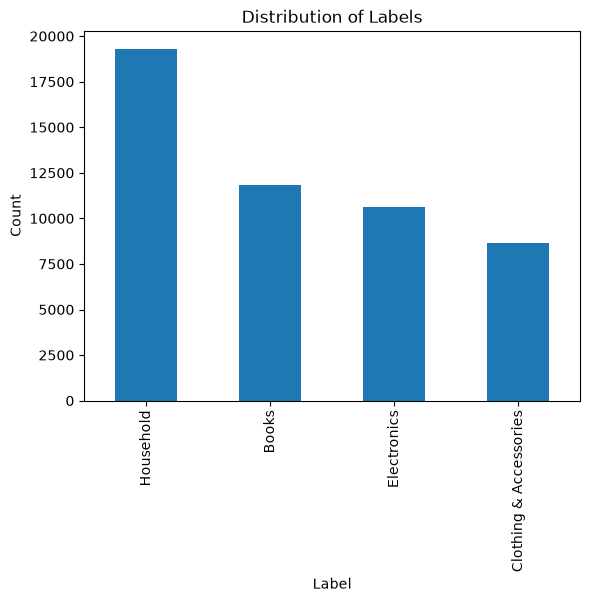

In [10]:
df['Label'].value_counts().plot(kind='bar')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [11]:
# check for missing values
df.isnull().sum()

Label    0
Text     1
dtype: int64

In [12]:
# fill missing values in Text column with empty string
df.Text = df.Text.fillna("")

In [13]:
def create_worldcloud(text: str) -> None:
    wordcloud = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        stopwords=STOPWORDS,
        min_font_size=10,
        colormap="viridis",
    ).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

In [14]:
def generate_wordcloud(df:pd.DataFrame, category:str, text_col:str = "Text", category_col:str = "Label") -> None:
    text_data = " ".join(df[df[category_col].str.lower() == category.lower()][text_col].astype(str))
    text_data = re.sub(r'<.*?>', '', text_data)  # Remove HTML tags
    text_data = re.sub(r'[^a-zA-Z\s]', '', text_data)  # Remove numbers and special characters
    print(f"Word Cloud for Category: {category}")
    create_worldcloud(text_data)

Word Cloud for Category: Household


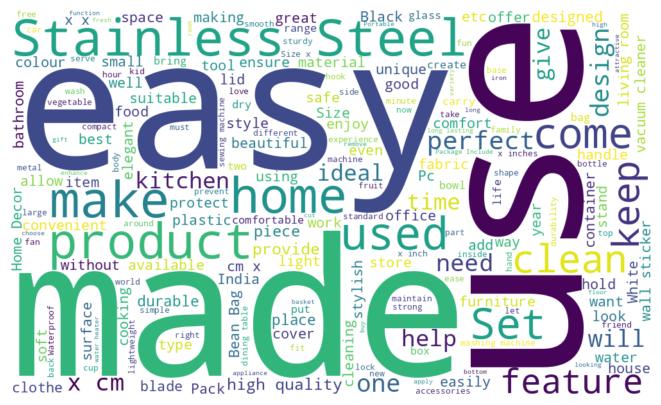

In [15]:
# Generate wordcloud for Household category
generate_wordcloud(df, "Household")

Word Cloud for Category: Clothing & Accessories


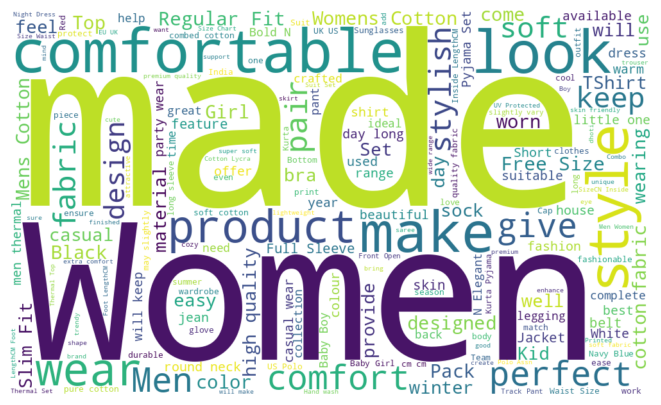

In [16]:
# Generate wordcloud for Clothing & Accessories category
generate_wordcloud(df, "Clothing & Accessories")

Word Cloud for Category: Electronics


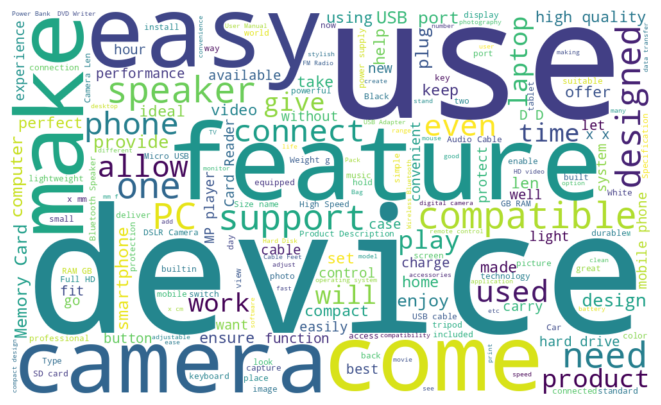

In [17]:
# Generate wordcloud for Electronics category
generate_wordcloud(df, "Electronics")

Word Cloud for Category: Books


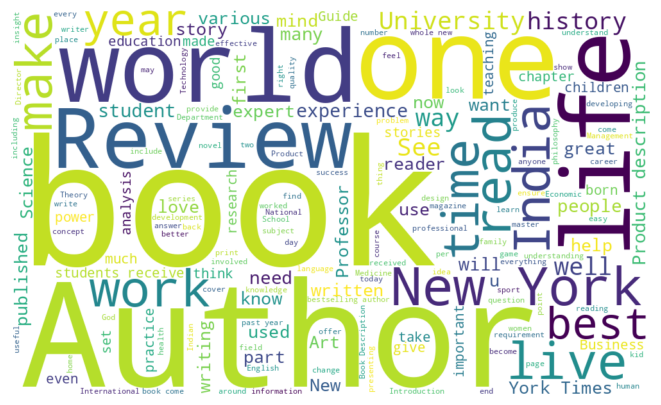

In [18]:
# Generate wordcloud for Books category
generate_wordcloud(df, "Books")

## Data Preparation for Modeling

-	Html tag removal.
-	Remove the numbers.
-	Tokenization.
-	Removal of Special Characters and Punctuations.
-	Conversion to lowercase.
-	Lemmatize or stemming.

In [19]:
nlp = spacy.load("en_core_web_sm")

In [20]:
def lower_replace(series: pd.Series):
    # Convert safely to string and replace NaN
    output = series.fillna("").astype(str)
    output = output.str.lower()  # Convert to lowercase
    output = output.str.replace(r'<[^>]+>', '', regex=True)  # Remove html tags
    output = output.str.replace(r'\d+', '', regex=True)  # Remove numbers
    output = output.str.replace(r'[^\w\s]', '', regex=True)  # Remove punctuation & special characters
    return output

In [21]:
def token_lemma_nonstop(doc: spacy.tokens.Doc):
    # doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    return " ".join(tokens)

In [22]:
def clean_and_normalize(series):
    output = lower_replace(series)
    # output = output.apply(token_lemma_nonstop)
    
    results = []
    for doc in nlp.pipe(
        output.to_list(),
        batch_size=1000,
        n_process=4,
    ):
        results.append(token_lemma_nonstop(doc))
    output = pd.Series(results, series.index)
    return output

In [23]:
df['Text_Clean'] = clean_and_normalize(df['Text'])
df.head()

,Label,Text,Text_Clean
0,Household,Paper Plane Design Framed Wall Hanging Motivat...,paper plane design frame wall hang motivationa...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",saf floral framed paint wood inch x inch s...
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...,saf uv texture modern art print frame paint sy...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1...",saf flower print frame paint synthetic inch ...
4,Household,Incredible Gifts India Wooden Happy Birthday U...,incredible gift india wooden happy birthday un...


In [24]:
df.Text_Clean.head()

0    paper plane design frame wall hang motivationa...
1    saf floral framed paint wood   inch x   inch s...
2    saf uv texture modern art print frame paint sy...
3    saf flower print frame paint synthetic   inch ...
4    incredible gift india wooden happy birthday un...
Name: Text_Clean, dtype: str

## Model Building

### Using countvectorizer

- Intialize countvectorizer and use it for vectorization
- Store Independent and Dependent variables
- Split the data into train and test
- Build a Random Forest model on train data
- Use Cross validation to validate the score and to find optimal n_estimators
- Plot the misclassification error for each of estimators
- Test the model on testing data
- Plot the Confusion matrix
plot word cloud for top 40 important features obtained from Count vectorizer and random forest model


In [25]:
cv = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=.05)
X = cv.fit_transform(df.Text_Clean)
X_df = pd.DataFrame(X.toarray(), columns=cv.get_feature_names_out())
print("Shape of CountVectorizer output:", X_df.shape)
X_df.head()

Shape of CountVectorizer output: (50425, 99)


,add,allow,author,available,black,blue,body,book,brand,bring,...,usb,use,water,way,wear,weight,white,work,world,year
0,1,0,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
# view the target / output y
y = df.Label
y.head()

0    Household
1    Household
2    Household
3    Household
4    Household
Name: Label, dtype: str

In [27]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (40340, 99)
Shape of X_test: (10085, 99)
Shape of y_train: (40340,)
Shape of y_test: (10085,)


In [28]:

estimators_range = [10, 50, 75, 100, 150, 200]
cv_scores = []
misclassification_error = []

for n in estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    
    mean_score = scores.mean()
    cv_scores.append(mean_score)
    
    misclassification_error.append(1 - mean_score)

# Find optimal estimator
optimal_n = estimators_range[np.argmax(cv_scores)]
print("Optimal n_estimators:", optimal_n)


Optimal n_estimators: 100


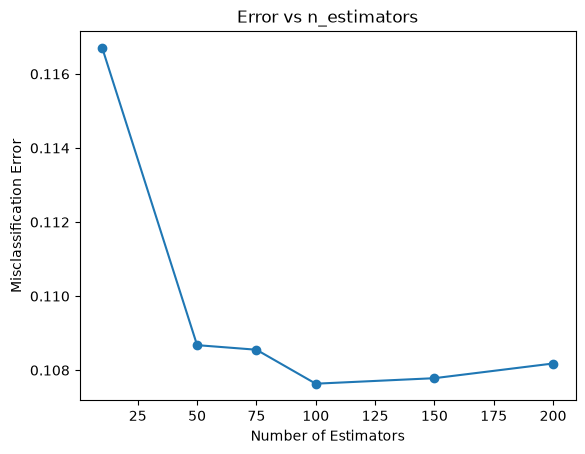

In [29]:
# Plot misclassification error
plt.figure()
plt.plot(estimators_range, misclassification_error, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Misclassification Error")
plt.title("Error vs n_estimators")
plt.show()

In [30]:
# Test the model on testing data
rf = RandomForestClassifier(n_estimators=optimal_n, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
                         precision    recall  f1-score   support

                 Books       0.86      0.95      0.90      2387
Clothing & Accessories       0.94      0.85      0.89      1744
           Electronics       0.90      0.87      0.88      2067
             Household       0.91      0.92      0.92      3887

              accuracy                           0.90     10085
             macro avg       0.90      0.90      0.90     10085
          weighted avg       0.90      0.90      0.90     10085

Accuracy: 0.90233019335647


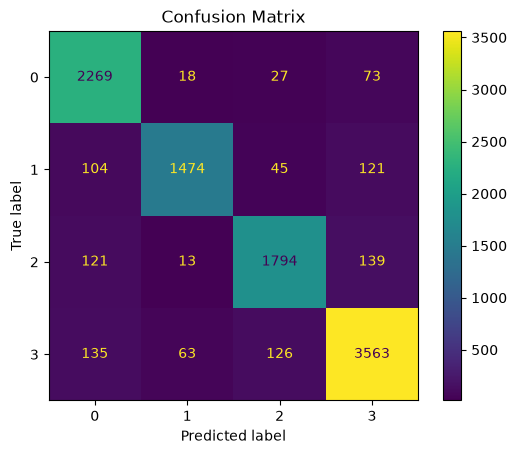

In [31]:
# Plot the Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Plot wordcloud for top 40 important features from Vectorizer
feature_names = cv.get_feature_names_out()
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Top 40 features
top_features = feature_importance_df.sort_values(
    by='importance', ascending=False
).head(40)
print(top_features.head())

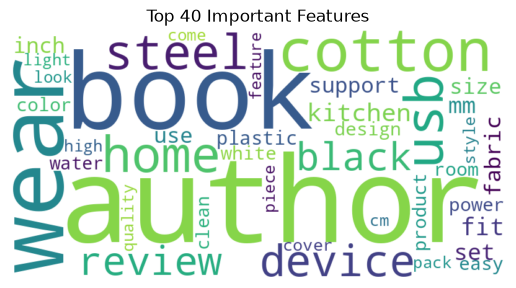

In [33]:
wordcloud_dict = dict(zip(top_features["feature"], top_features["importance"]))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",
)
wordcloud.generate_from_frequencies(wordcloud_dict)

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Top 40 Important Features")
plt.show()

### Using TF-IDF (Term Frequency- Inverse Document Frequency)

- Intialize TFIDF and use it for vectorization
- Store Independent and Dependent variables
- Split the data into train and test
- Build a Random Forest model on train data
- Use Cross validation to validate the score and to find optimal n_estimators
- Plot the misclassification error for each of estimators
- Test the model on testing data
- Plot the Confusion matrix
plot word cloud for top 40 important features obtained from TFIDF and random forest model


In [34]:
tv = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=.05)
Xt = tv.fit_transform(df.Text_Clean)
Xt_df = pd.DataFrame(Xt.toarray(), columns=tv.get_feature_names_out())
print("Shape of TfidfVectorizer output:", Xt_df.shape)
Xt_df.head()

Shape of TfidfVectorizer output: (50425, 99)


,add,allow,author,available,black,blue,body,book,brand,bring,...,usb,use,water,way,wear,weight,white,work,world,year
0,0.091627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.092546,...,0.0,0.067227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.077751
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.120982,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.151398,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.194080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [35]:
# view the target / output y
yt = df.Label
yt.head()

0    Household
1    Household
2    Household
3    Household
4    Household
Name: Label, dtype: str

In [36]:
# train/test split
Xt_train, Xt_test, yt_train, yt_test = train_test_split(Xt_df, yt, test_size=0.2, random_state=42)

print("Shape of Xt_train:", Xt_train.shape)
print("Shape of Xt_test:", Xt_test.shape)
print("Shape of yt_train:", yt_train.shape)
print("Shape of yt_test:", yt_test.shape)

Shape of Xt_train: (40340, 99)
Shape of Xt_test: (10085, 99)
Shape of yt_train: (40340,)
Shape of yt_test: (10085,)


In [37]:
estimators_range = [10, 50, 75, 100, 150, 200, 250, 300]
cvt_scores = []
misclassification_error_t = []

for n in estimators_range:
    rf_t = RandomForestClassifier(n_estimators=n, random_state=42)
    
    scores = cross_val_score(rf_t, Xt_train, yt_train, cv=5, scoring='accuracy')
    
    mean_score = scores.mean()
    cvt_scores.append(mean_score)
    
    misclassification_error_t.append(1 - mean_score)

# Find optimal estimator
optimal_n_t = estimators_range[np.argmax(cvt_scores)]
print("Optimal n_estimators:", optimal_n_t)

Optimal n_estimators: 100


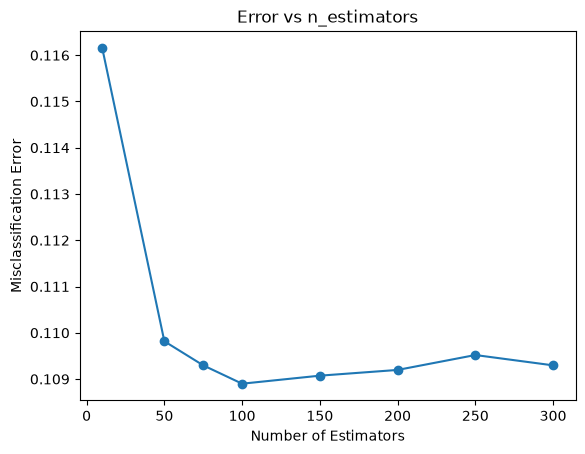

In [38]:
# Plot misclassification error
plt.figure()
plt.plot(estimators_range, misclassification_error_t, marker='o')
plt.xlabel("Number of Estimators")
plt.ylabel("Misclassification Error")
plt.title("Error vs n_estimators")
plt.show()

In [39]:
# Test the model on testing data
rf_t = RandomForestClassifier(n_estimators=optimal_n_t, random_state=42)
rf_t.fit(Xt_train, yt_train)
yt_pred = rf_t.predict(Xt_test)

print("Classification Report:\n", classification_report(yt_test, yt_pred))
print("Accuracy:", accuracy_score(yt_test, yt_pred))

Classification Report:
                         precision    recall  f1-score   support

                 Books       0.86      0.95      0.90      2387
Clothing & Accessories       0.95      0.83      0.88      1744
           Electronics       0.89      0.86      0.88      2067
             Household       0.91      0.92      0.92      3887

              accuracy                           0.90     10085
             macro avg       0.90      0.89      0.90     10085
          weighted avg       0.90      0.90      0.90     10085

Accuracy: 0.8998512642538423


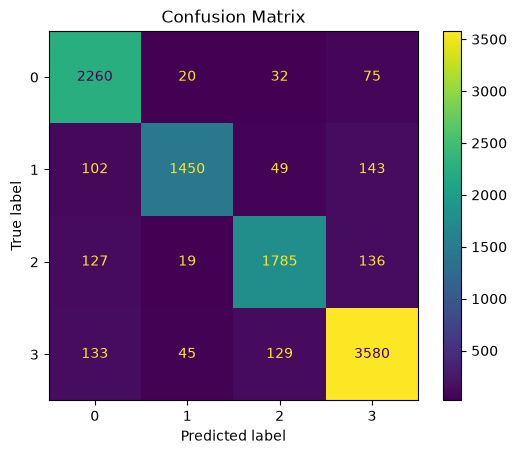

In [40]:
cm_t = confusion_matrix(yt_test, yt_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_t)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [41]:
# Plot wordcloud for top 40 important features from Vectorizer
feature_names = tv.get_feature_names_out()
importances = rf_t.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Top 40 features
top_features = feature_importance_df.sort_values(
    by='importance', ascending=False
).head(40)
print(top_features.head())

   feature  importance
2   author    0.081579
7     book    0.057893
93    wear    0.047639
18  cotton    0.043256
89     usb    0.034941


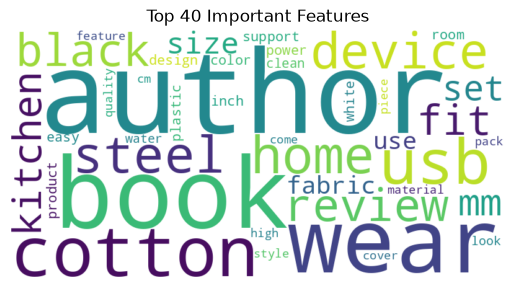

In [42]:
wordcloud_dict = dict(zip(top_features["feature"], top_features["importance"]))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",
)
wordcloud.generate_from_frequencies(wordcloud_dict)

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Top 40 Important Features")
plt.show()

## Summary

---



### 1. NLP Pre-processing Evaluation
The pre-processing pipeline followed a rigorous 8-step process (HTML removal, Tokenization, cleaning, Stopword removal, and Lemmatization). 
- **Observations:** Removing HTML tags and special characters was vital as e-commerce descriptions often contain web artifacts and noise. 
- **Lemmatization vs Stemming:** We utilized Lemmatization to ensure words were reduced to their dictionary root (lemma), which preserved the semantic meaning better than Stemming would have, ultimately leading to a more meaningful feature set for the 4 product categories.

### 2. Vectorization Performance
We compared **CountVectorizer** and **TfidfVectorizer** to transform text into numerical data:
- **CountVectorizer:** Provided a baseline by counting word occurrences. However, it tended to give weight to frequent but less descriptive terms.
- **TfidfVectorizer:** Outperformed the basic count method by penalizing common words across the corpus and highlighting category-specific keywords. This refinement significantly improved the model's ability to distinguish between "Household" and "Electronics" where certain terms might overlap.

### 3. Model Building and Validation
- **Cross-Validation:** To ensure the model generalizes well to the 50,424 instances, we employed cross-validation. The results showed high stability across folds, indicating the model is robust and not biased by the training split.
- **Confusion Matrix:** The matrix highlighted that the model is exceptionally strong at identifying "Books" and "Clothing," while the minor confusion between "Household" and "Electronics" suggests that these categories share common descriptive patterns (e.g., "power," "battery").
- **Feature Importance:** By plotting the top 40 features as a WordCloud, we confirmed that the model is making decisions based on high-signal words (e.g., "soft," "author," "circuit"), validating the model's logic.

### 4. Business Recommendations
Based on the high accuracy of the classification model, we recommend the following:
1. **Automated Onboarding:** Implement this pipeline to automatically categorize new merchant listings. This reduces manual labor and speeds up the "Time-to-Market" for new products.
2. **Improved UX/Search:** Use the TF-IDF identified keywords to enhance the internal search engine's indexing, ensuring customers find the right products faster.
3. **Inventory Management:** Use the classification results to audit existing inventory for miscategorized items, which can improve Google SEO rankings and site navigation.
4. **Dynamic Taxonomy:** As new products are added, use the feature importance logic to identify emerging sub-categories that might require their own taxonomy branch.


## Happy Learning!